## Artificial Neural Networks and Deep Learning
#### Challenge 1 - Year 2025/2026
#### Team: Va Alianza Toca la U

*   Luis Caballero Fritas
*   Camilo Martínez Mejía
*   Daffer Queque Palomino
*   Reinaldo Toledo Leguizamón


Notebook: Preprocessing, Training and Evaluation


In [ ]:
! pwd

/home/luis/ai2dl/notebooks


#### Mounting google drive

In [ ]:
# from google.colab import drive
# drive.mount("/content/drive")
# current_dir = "/gdrive/My\\ Drive/[2025-2026]\\ AN2DL/Lecture\\ 1"
# %cd $current_dir

#### Import Libraries

In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.8.0+cu128
Device: cuda


In [ ]:
## We verify to set seed to 42 for reproducibility
def seed_everything(seed=42):
    import torch, random, numpy as np, os

    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

#### Data Loading

In [ ]:
# Read the dataset into a DataFrame with specified column names
x_train_kaggle = pd.read_csv('pirate_pain_train.csv')
y_train_kaggle = pd.read_csv('pirate_pain_train_labels.csv')

test_kaggle = pd.read_csv('pirate_pain_test.csv')

# Print the shape of the DataFrame
print(f"Train X DataFrame shape: {x_train_kaggle.shape}")
print(f"Train Y DataFrame shape: {y_train_kaggle.shape}")

# Display the first 10 rows of the DataFrame
x_train_kaggle.head(10)

Train X DataFrame shape: (105760, 40)
Train Y DataFrame shape: (661, 2)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.500000e-06,1.950000e-06,4.000000e-06,1.150000e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.980000e-07,6.770000e-07,6.020000e-06,4.640000e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.530000e-07,1.700000e-07,1.450000e-06,2.420000e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.010000e-05,5.510000e-07,1.850000e-06,5.430000e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.440000e-06,1.740000e-07,1.550000e-06,5.830000e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5
5,0,5,2,0,2,1,two,two,two,1.146031,...,1.070000e-06,1.750000e-07,2.960000e-07,6.220000e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5
6,0,6,2,1,2,1,two,two,two,1.025870,...,1.070000e-06,1.770000e-07,1.980000e-06,1.580000e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5
7,0,7,2,2,2,2,two,two,two,1.038597,...,8.830000e-07,1.790000e-07,2.210000e-06,1.490000e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5
8,0,8,2,2,0,1,two,two,two,0.984251,...,1.620000e-06,1.170000e-06,3.030000e-07,5.420000e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5
9,0,9,0,2,2,2,two,two,two,1.054999,...,1.610000e-06,3.960000e-06,2.020000e-06,1.150000e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5


In [ ]:
# Training data shape
x_train_kaggle.shape

(105760, 40)

In [ ]:
# We swow statistical metrics of X_train
x_train_kaggle.describe()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
count,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,...,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,105760.000000,105760.000000,105760.000000,105760.000000,105760.0
mean,330.000000,79.500000,1.633746,1.654851,1.653640,1.663134,0.943095,0.916955,0.779296,0.767921,...,3.972126e-05,4.176802e-05,3.561779e-05,3.138109e-05,1.024605e-04,0.041905,0.058244,0.049886,0.062273,0.5
std,190.814948,46.187338,0.682423,0.669639,0.666649,0.661994,0.202051,0.197608,0.295605,0.300787,...,4.974496e-03,5.472244e-03,1.235450e-03,4.062914e-04,3.206128e-03,0.060293,0.079819,0.060773,0.072597,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001015,0.005403,...,0.000000e+00,1.510000e-07,0.000000e+00,1.060000e-08,0.000000e+00,0.000203,0.000000,0.000000,0.000000,0.5
25%,165.000000,39.750000,2.000000,2.000000,2.000000,2.000000,0.828277,0.811445,0.568850,0.520020,...,6.550000e-08,3.320000e-07,3.280000e-07,2.840000e-07,7.160000e-07,0.009885,0.012652,0.016290,0.019638,0.5
50%,330.000000,79.500000,2.000000,2.000000,2.000000,2.000000,1.005126,0.979468,0.909549,0.914834,...,8.300000e-07,1.100000e-06,1.020000e-06,8.750000e-07,3.130000e-06,0.021898,0.031739,0.031843,0.039041,0.5
75%,495.000000,119.250000,2.000000,2.000000,2.000000,2.000000,1.081039,1.056611,0.995187,0.994324,...,2.800000e-06,3.080000e-06,3.020000e-06,2.510000e-06,9.950000e-06,0.048579,0.071051,0.058741,0.079518,0.5
max,660.000000,159.000000,2.000000,2.000000,2.000000,2.000000,1.407968,1.334613,1.306046,1.254729,...,1.442198e+00,1.305001e+00,2.742411e-01,3.643074e-02,9.473540e-01,1.223617,1.187419,1.412037,1.370765,0.5


In [ ]:
#Statistical metrics of y_train
y_train_kaggle.describe()

,sample_index
count,661.000000
mean,330.000000
std,190.958547
min,0.000000
25%,165.000000
50%,330.000000
75%,495.000000
max,660.000000


In [ ]:
# Display a concise summary of the DataFrame
x_train_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 40 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  int64  
 1   time           105760 non-null  int64  
 2   pain_survey_1  105760 non-null  int64  
 3   pain_survey_2  105760 non-null  int64  
 4   pain_survey_3  105760 non-null  int64  
 5   pain_survey_4  105760 non-null  int64  
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float64
 10  joint_01       105760 non-null  float64
 11  joint_02       105760 non-null  float64
 12  joint_03       105760 non-null  float64
 13  joint_04       105760 non-null  float64
 14  joint_05       105760 non-null  float64
 15  joint_06       105760 non-null  float64
 16  joint_07       105760 non-null  float64
 17  joint_08       105760 non-nul

### Data preprocessing

In [ ]:
# Searching for null values
x_train_kaggle.isnull().sum()

sample_index     0
time             0
pain_survey_1    0
pain_survey_2    0
pain_survey_3    0
pain_survey_4    0
n_legs           0
n_hands          0
n_eyes           0
joint_00         0
joint_01         0
joint_02         0
joint_03         0
joint_04         0
joint_05         0
joint_06         0
joint_07         0
joint_08         0
joint_09         0
joint_10         0
joint_11         0
joint_12         0
joint_13         0
joint_14         0
joint_15         0
joint_16         0
joint_17         0
joint_18         0
joint_19         0
joint_20         0
joint_21         0
joint_22         0
joint_23         0
joint_24         0
joint_25         0
joint_26         0
joint_27         0
joint_28         0
joint_29         0
joint_30         0
dtype: int64

In [ ]:
## For train data

# We convert int64 to int32 and float 64 to float 32
for col in x_train_kaggle.columns:
  if x_train_kaggle[col].dtype == 'int64':
    # Convert column to int32 data type
    x_train_kaggle[col] = x_train_kaggle[col].astype(np.int32)
  elif x_train_kaggle[col].dtype == 'float64':
    #Convert column to float32 data type
    x_train_kaggle[col] = x_train_kaggle[col].astype(np.float32)

# We convert pain_survey_x values from int32 (this was obtained in the aboved loop) to float32
x_train_kaggle['pain_survey_1'] = x_train_kaggle['pain_survey_1'].astype(np.float32)
x_train_kaggle['pain_survey_2'] = x_train_kaggle['pain_survey_2'].astype(np.float32)
x_train_kaggle['pain_survey_3'] = x_train_kaggle['pain_survey_3'].astype(np.float32)
x_train_kaggle['pain_survey_4'] = x_train_kaggle['pain_survey_4'].astype(np.float32)

In [ ]:
## For test data

#We convert the same for the test_kaggle data
for col in test_kaggle.columns:
  if test_kaggle[col].dtype == 'int64':
    # Convert column to int32 data type
    test_kaggle[col] = test_kaggle[col].astype(np.int32)
  elif test_kaggle[col].dtype == 'float64':
    #Convert column to float32 data type
    test_kaggle[col] = test_kaggle[col].astype(np.float32)

test_kaggle['pain_survey_1'] = test_kaggle['pain_survey_1'].astype(np.float32)
test_kaggle['pain_survey_2'] = test_kaggle['pain_survey_2'].astype(np.float32)
test_kaggle['pain_survey_3'] = test_kaggle['pain_survey_3'].astype(np.float32)
test_kaggle['pain_survey_4'] = test_kaggle['pain_survey_4'].astype(np.float32)

In [ ]:
# Test data info to verify data type conversions
test_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211840 entries, 0 to 211839
Data columns (total 40 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   211840 non-null  int32  
 1   time           211840 non-null  int32  
 2   pain_survey_1  211840 non-null  float32
 3   pain_survey_2  211840 non-null  float32
 4   pain_survey_3  211840 non-null  float32
 5   pain_survey_4  211840 non-null  float32
 6   n_legs         211840 non-null  object 
 7   n_hands        211840 non-null  object 
 8   n_eyes         211840 non-null  object 
 9   joint_00       211840 non-null  float32
 10  joint_01       211840 non-null  float32
 11  joint_02       211840 non-null  float32
 12  joint_03       211840 non-null  float32
 13  joint_04       211840 non-null  float32
 14  joint_05       211840 non-null  float32
 15  joint_06       211840 non-null  float32
 16  joint_07       211840 non-null  float32
 17  joint_08       211840 non-nul

In [ ]:
# Quantity of samples (time series groups)
x_train_kaggle['sample_index'].nunique()

661

In [ ]:
# Info of training output data
y_train_kaggle.head(10)
y_train_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 661 entries, 0 to 660
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sample_index  661 non-null    int64 
 1   label         661 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.5+ KB


In [ ]:
# Displaying training data
x_train_kaggle.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2.0,0.0,2.0,1.0,two,two,two,1.094705,...,3.500000e-06,1.950000e-06,0.000004,1.150000e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2.0,2.0,2.0,2.0,two,two,two,1.135183,...,3.980000e-07,6.770000e-07,0.000006,4.640000e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2.0,0.0,2.0,2.0,two,two,two,1.080745,...,1.530000e-07,1.700000e-07,0.000001,2.420000e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2.0,2.0,2.0,2.0,two,two,two,0.938017,...,1.010000e-05,5.510000e-07,0.000002,5.430000e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2.0,2.0,2.0,2.0,two,two,two,1.090185,...,4.440000e-06,1.740000e-07,0.000002,5.830000e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5


In [ ]:
# We make a copy of the training X and y data
df_x_train = x_train_kaggle.copy()
df_y_train = y_train_kaggle.copy()

In [ ]:
# We merge the datasets if needed
df_y_train = df_y_train.set_index("sample_index")
xy_df = df_x_train.join(df_y_train, on="sample_index")

In [ ]:
## For simple training we can manually split data ##

# Get unique user IDs and shuffle them
unique_users = xy_df['sample_index'].unique()
random.seed(SEED) # Ensure reproducibility of shuffling
random.shuffle(unique_users)

# Define the number of users for validation and test sets
N_VAL_USERS = 198 # You can change this number
#N_TEST_USERS = 132 # You can change this number

# Calculate the number of users for the training set
n_train_users = len(unique_users) - N_VAL_USERS #- N_TEST_USERS
print(n_train_users)

# Split the shuffled user IDs into training, validation, and test sets
train_users = unique_users[:n_train_users]
val_users = unique_users[n_train_users:n_train_users + N_VAL_USERS]
#test_users = unique_users[n_train_users + N_VAL_USERS:]

# Split the dataset into training, validation, and test sets based on user IDs
df_train = xy_df[xy_df['sample_index'].isin(train_users)]
df_val = xy_df[xy_df['sample_index'].isin(val_users)]
#df_test = xy_df[xy_df['sample_index'].isin(test_users)]

# Print the shapes of the training, validation, and test sets
print(f'Training set shape: {df_train.shape}')
print(f'Validation set shape: {df_val.shape}')
#print(f'Test set shape: {df_test.shape}')
print(f'Unique values in sample_index col in Training set: {len(df_train['sample_index'].unique())}')
print(f'Unique values in sample_index col in Validation set: {len(df_val['sample_index'].unique())}')

463
Training set shape: (74080, 41)
Validation set shape: (31680, 41)
Unique values in sample_index col in Training set: 463
Unique values in sample_index col in Validation set: 198


In [ ]:
# Initialise a dictionary to count occurrences of each activity in the training set
training_labels = {
    'no_pain': 0,
    'low_pain': 0,
    'high_pain': 0,
}

# Count occurrences of each activity for unique IDs in the training set
for id in df_train['sample_index'].unique():
    label = df_train[df_train['sample_index'] == id]['label'].values[0]
    training_labels[label] += 1

# Print the distribution of training labels
print('Training labels:', training_labels)

Training labels: {'no_pain': 365, 'low_pain': 64, 'high_pain': 34}


In [ ]:
#Display top rows
df_train.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
160,1,0,2.0,1.0,2.0,2.0,two,two,two,1.233603,...,1.790000e-07,3.010000e-07,7.000000e-08,0.000000e+00,0.038205,0.071314,0.167005,0.071224,0.5,no_pain
161,1,1,2.0,2.0,2.0,2.0,two,two,two,1.282773,...,4.260000e-07,3.030000e-07,1.750000e-06,3.590000e-07,0.042063,0.092794,0.313285,0.109012,0.5,no_pain
162,1,2,2.0,2.0,2.0,2.0,two,two,two,1.152013,...,1.830000e-07,7.880000e-07,2.490000e-06,2.660000e-07,0.028804,0.114392,0.180912,0.057898,0.5,no_pain
163,1,3,2.0,2.0,1.0,0.0,two,two,two,1.220093,...,6.830000e-07,1.650000e-06,8.160000e-08,0.000000e+00,0.013567,0.055338,0.177194,0.084191,0.5,no_pain
164,1,4,2.0,2.0,2.0,2.0,two,two,two,1.099697,...,1.860000e-07,1.780000e-06,8.540000e-08,2.980000e-06,0.052765,0.040712,0.176549,0.082932,0.5,no_pain


In [ ]:
# Initialise a dictionary to count occurrences of each activity in the validation set
val_labels = {
    'no_pain': 0,
    'low_pain': 0,
    'high_pain': 0
}

# Count occurrences of each activity for unique IDs in the validation set
for id in df_val['sample_index'].unique():
    label = df_val[df_val['sample_index'] == id]['label'].values[0]
    val_labels[label] += 1

# Print the distribution of validation labels
print('Validation labels:', val_labels)

total_count=0 # Renamed 'sum' to 'total_count' to avoid shadowing the built-in sum function
for key, value in val_labels.items():
    print(f"{key}: {value}")
    total_count=total_count+value
print(total_count)

Validation labels: {'no_pain': 146, 'low_pain': 30, 'high_pain': 22}
no_pain: 146
low_pain: 30
high_pain: 22
198


In [ ]:
# Define a mapping of activity names to integer labels
label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2,
}

# Map activity names to integers in the training set
df_train['label'] = df_train['label'].map(label_mapping)

# Map activity names to integers in the validation set
df_val['label'] = df_val['label'].map(label_mapping)

In [ ]:
# Define a mapping of activity names to integer labels
legs_mapping = {
    'two': 0,
    'one+peg_leg': 1
}

# Map activity names to integers in the training set
df_train['n_legs'] = df_train['n_legs'].map(legs_mapping)

# Map activity names to integers in the validation set
df_val['n_legs'] = df_val['n_legs'].map(legs_mapping)

# Map activity names to integers in the test set
test_kaggle['n_legs'] = test_kaggle['n_legs'].map(legs_mapping)

In [ ]:
# Define a mapping of activity names to integer labels
hands_mapping = {
    'two': 0,
    'one+hook_hand': 1
}

# Map activity names to integers in the training set
df_train['n_hands'] = df_train['n_hands'].map(hands_mapping)

# Map activity names to integers in the validation set
df_val['n_hands'] = df_val['n_hands'].map(hands_mapping)

# Map activity names to integers in the test set
test_kaggle['n_hands'] = test_kaggle['n_hands'].map(hands_mapping)

In [ ]:
df_train.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
160,1,0,2.0,1.0,2.0,2.0,0,0,two,1.233603,...,1.790000e-07,3.010000e-07,7.000000e-08,0.000000e+00,0.038205,0.071314,0.167005,0.071224,0.5,0
161,1,1,2.0,2.0,2.0,2.0,0,0,two,1.282773,...,4.260000e-07,3.030000e-07,1.750000e-06,3.590000e-07,0.042063,0.092794,0.313285,0.109012,0.5,0
162,1,2,2.0,2.0,2.0,2.0,0,0,two,1.152013,...,1.830000e-07,7.880000e-07,2.490000e-06,2.660000e-07,0.028804,0.114392,0.180912,0.057898,0.5,0
163,1,3,2.0,2.0,1.0,0.0,0,0,two,1.220093,...,6.830000e-07,1.650000e-06,8.160000e-08,0.000000e+00,0.013567,0.055338,0.177194,0.084191,0.5,0
164,1,4,2.0,2.0,2.0,2.0,0,0,two,1.099697,...,1.860000e-07,1.780000e-06,8.540000e-08,2.980000e-06,0.052765,0.040712,0.176549,0.082932,0.5,0


In [ ]:
# Define a mapping of activity names to integer labels
eyes_mapping = {
    'two': 0,
    'one+eye_patch': 1
}

# Map activity names to integers in the training set
df_train['n_eyes'] = df_train['n_eyes'].map(eyes_mapping)

# Map activity names to integers in the validation set
df_val['n_eyes'] = df_val['n_eyes'].map(eyes_mapping)

# Map activity names to integers in the validation set
test_kaggle['n_eyes'] = test_kaggle['n_eyes'].map(eyes_mapping)

In [ ]:
#Converting values to float32
df_train['n_legs'] = df_train['n_legs'].astype(np.float32)
df_train['n_hands'] = df_train['n_hands'].astype(np.float32)
df_train['n_eyes'] = df_train['n_eyes'].astype(np.float32)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74080 entries, 160 to 105439
Data columns (total 41 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_index   74080 non-null  int32  
 1   time           74080 non-null  int32  
 2   pain_survey_1  74080 non-null  float32
 3   pain_survey_2  74080 non-null  float32
 4   pain_survey_3  74080 non-null  float32
 5   pain_survey_4  74080 non-null  float32
 6   n_legs         74080 non-null  float32
 7   n_hands        74080 non-null  float32
 8   n_eyes         74080 non-null  float32
 9   joint_00       74080 non-null  float32
 10  joint_01       74080 non-null  float32
 11  joint_02       74080 non-null  float32
 12  joint_03       74080 non-null  float32
 13  joint_04       74080 non-null  float32
 14  joint_05       74080 non-null  float32
 15  joint_06       74080 non-null  float32
 16  joint_07       74080 non-null  float32
 17  joint_08       74080 non-null  float32
 18  joint_09

In [ ]:
#Convert values to float32 in validation dataset
df_val['n_legs'] = df_val['n_legs'].astype(np.float32)
df_val['n_hands'] = df_val['n_hands'].astype(np.float32)
df_val['n_eyes'] = df_val['n_eyes'].astype(np.float32)
df_val.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31680 entries, 0 to 105759
Data columns (total 41 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sample_index   31680 non-null  int32  
 1   time           31680 non-null  int32  
 2   pain_survey_1  31680 non-null  float32
 3   pain_survey_2  31680 non-null  float32
 4   pain_survey_3  31680 non-null  float32
 5   pain_survey_4  31680 non-null  float32
 6   n_legs         31680 non-null  float32
 7   n_hands        31680 non-null  float32
 8   n_eyes         31680 non-null  float32
 9   joint_00       31680 non-null  float32
 10  joint_01       31680 non-null  float32
 11  joint_02       31680 non-null  float32
 12  joint_03       31680 non-null  float32
 13  joint_04       31680 non-null  float32
 14  joint_05       31680 non-null  float32
 15  joint_06       31680 non-null  float32
 16  joint_07       31680 non-null  float32
 17  joint_08       31680 non-null  float32
 18  joint_09  

In [ ]:
# displaying datatypes of test dataset
test_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211840 entries, 0 to 211839
Data columns (total 40 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   211840 non-null  int32  
 1   time           211840 non-null  int32  
 2   pain_survey_1  211840 non-null  float32
 3   pain_survey_2  211840 non-null  float32
 4   pain_survey_3  211840 non-null  float32
 5   pain_survey_4  211840 non-null  float32
 6   n_legs         211840 non-null  int64  
 7   n_hands        211840 non-null  int64  
 8   n_eyes         211840 non-null  int64  
 9   joint_00       211840 non-null  float32
 10  joint_01       211840 non-null  float32
 11  joint_02       211840 non-null  float32
 12  joint_03       211840 non-null  float32
 13  joint_04       211840 non-null  float32
 14  joint_05       211840 non-null  float32
 15  joint_06       211840 non-null  float32
 16  joint_07       211840 non-null  float32
 17  joint_08       211840 non-nul

In [ ]:
# Conversion to float32 in test dataset
test_kaggle['n_legs'] = test_kaggle['n_legs'].astype(np.float32)
test_kaggle['n_hands'] = test_kaggle['n_hands'].astype(np.float32)
test_kaggle['n_eyes'] = test_kaggle['n_eyes'].astype(np.float32)
test_kaggle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211840 entries, 0 to 211839
Data columns (total 40 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   211840 non-null  int32  
 1   time           211840 non-null  int32  
 2   pain_survey_1  211840 non-null  float32
 3   pain_survey_2  211840 non-null  float32
 4   pain_survey_3  211840 non-null  float32
 5   pain_survey_4  211840 non-null  float32
 6   n_legs         211840 non-null  float32
 7   n_hands        211840 non-null  float32
 8   n_eyes         211840 non-null  float32
 9   joint_00       211840 non-null  float32
 10  joint_01       211840 non-null  float32
 11  joint_02       211840 non-null  float32
 12  joint_03       211840 non-null  float32
 13  joint_04       211840 non-null  float32
 14  joint_05       211840 non-null  float32
 15  joint_06       211840 non-null  float32
 16  joint_07       211840 non-null  float32
 17  joint_08       211840 non-nul

In [ ]:
### We define a window_size and stride for a simple training

# Define the window size
WINDOW_SIZE = 40

# Define the stride for overlapping windows
STRIDE = 20

# Including all pain surveys, subject characteristics and all joints

# list of joints
# feature_list = ['pain_survey_1','pain_survey_2','pain_survey_3','pain_survey_4',
#                 'n_legs','n_hands','n_eyes',
#                 'joint_00','joint_01','joint_02','joint_03','joint_04','joint_05',
#               'joint_06','joint_07','joint_08','joint_09','joint_10','joint_11',
#               'joint_12','joint_13','joint_14','joint_15','joint_16','joint_17',
#               'joint_18','joint_19','joint_20','joint_21','joint_22','joint_23',
#               'joint_24','joint_25','joint_26','joint_27','joint_28','joint_29',
#               'joint_30']

# Including all pain surveys, subject characteristics and all joints unless joint30

feature_list = ['pain_survey_1','pain_survey_2','pain_survey_3','pain_survey_4',
                'n_legs','n_hands','n_eyes',
                'joint_00','joint_01','joint_02','joint_03','joint_04','joint_05',
              'joint_06','joint_07','joint_08','joint_09','joint_10','joint_11',
              'joint_12','joint_13','joint_14','joint_15','joint_16','joint_17',
              'joint_18','joint_19','joint_20','joint_21','joint_22','joint_23',
              'joint_24','joint_25','joint_26','joint_27','joint_28','joint_29']

In [ ]:
# Define a function to build sequences from the dataset
def build_sequences(df, window, stride):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialise lists to store sequences and their corresponding labels
    dataset = []
    labels = []

    # Iterate over unique IDs in the DataFrame
    for id in df['sample_index'].unique():
        # Extract sensor data for the current ID
        temp = df[df['sample_index'] == id][feature_list].values

        # Retrieve the activity label for the current ID
        label = df[df['sample_index'] == id]['label'].values[0]

        # Calculate padding length to ensure full windows
        padding_len = window - len(temp) % window

        # Create zero padding and concatenate with the data
        #padding = np.zeros((padding_len, 35), dtype='float32')
        #temp = np.concatenate((temp, padding))

        # Build feature windows and associate them with labels
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            labels.append(label)
            idx += stride

    # Convert lists to numpy arrays for further processing
    dataset = np.array(dataset)
    labels = np.array(labels)

    return dataset, labels

In [ ]:
# Generate sequences and labels for the training set
X_train, y_train = build_sequences(df_train, WINDOW_SIZE, STRIDE)

# Generate sequences and labels for the validation set
X_val, y_val = build_sequences(df_val, WINDOW_SIZE, STRIDE)

# Generate sequences and labels for the test set
#X_test, y_test = build_sequences(df_test, WINDOW_SIZE, STRIDE)

# Print the shapes of the generated datasets and their labels
X_train.shape, y_train.shape, X_val.shape, y_val.shape #, X_test.shape, y_test.shape

((3241, 40, 37), (3241,), (1386, 40, 37), (1386,))

In [ ]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))

In [ ]:
# Define the input shape based on the training data
input_shape = X_train.shape[1:]


# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train))

In [ ]:
print(input_shape[-1])

37


In [ ]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 32

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))
    #num_workers = 0

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [ ]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
# Get one batch from the training data loader
for xb, yb in train_loader:
    print("Features batch shape:", xb.shape)
    print("Labels batch shape:", yb.shape)
    break # Stop after getting one batch

Features batch shape: torch.Size([32, 40, 37])
Labels batch shape: torch.Size([32])


In [ ]:
def recurrent_summary(model, input_size):
    """
    Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [ ]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',        # 'RNN', 'LSTM', or 'GRU'
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concat fwd + bwd
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x)

        # LSTM returns (h_n, c_n), we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # Reshape to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            # Concat last fwd (hidden[-1, 0, ...]) and bwd (hidden[-1, 1, ...])
            # Final shape: (batch_size, hidden_size * 2)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # Take the last layer's hidden state
            # Final shape: (batch_size, hidden_size)
            hidden_to_classify = hidden[-1]

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits


#Create model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes,
    dropout_rate=0.,
    rnn_type='RNN'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (RNN)                 [[-1, 40, 128], [2, -1, 128]] 54,400         
classifier (Linear)       [-1, 3]                      387            
Total params: 54,787
Trainable params: 54,787
Non-trainable params: 0
-------------------------------------------------------------------------------


#### Defininf Hyperparameters

In [ ]:
# BEST HYPERPARAMETER VALUES OBTAINED AFTER GRID SEARCH

# Training configuration
LEARNING_RATE = 5e-4
EPOCHS = 500 #500
PATIENCE = 50 #50

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128        # Neurons per layer 128

# Regularisation
DROPOUT_RATE = 0.2         # Dropout probability
L1_LAMBDA = 0            # L1 penalty
L2_LAMBDA = 1e-4            # L2 penalty

# Set up loss function and optimizer
criterion = nn.CrossEntropyLoss()

### Training

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [ ]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [ ]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """
    Log training metrics and model parameters to TensorBoard for visualization.

    Args:
        writer (SummaryWriter): TensorBoard SummaryWriter object for logging
        epoch (int): Current epoch number (used as x-axis in TensorBoard plots)
        train_loss (float): Training loss for this epoch
        train_f1 (float): Training f1 score for this epoch
        val_loss (float): Validation loss for this epoch
        val_f1 (float): Validation f1 score for this epoch
        model (nn.Module): The neural network model (for logging weights/gradients)

    Note:
        This function logs scalar metrics (loss/f1 score) and histograms of model
        parameters and gradients, which helps monitor training progress and detect
        issues like vanishing/exploding gradients.
    """
    # Log scalar metrics
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    # Log model parameters and gradients
    for name, param in model.named_parameters():
        if param.requires_grad:
            # Check if the tensor is not empty before adding a histogram
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None:
                # Check if the gradient tensor is not empty before adding a histogram
                if param.grad.numel() > 0:
                    if param.grad is not None and torch.isfinite(param.grad).all():
                        writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [ ]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        epochs (int): Number of training epochs
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): L1 regularization coefficient (default: 0)
        l2_lambda (float): L2 regularization coefficient (default: 0)
        patience (int): Number of epochs to wait for improvement before early stopping (default: 0)
        evaluation_metric (str): Metric to monitor for early stopping (default: "val_f1")
        mode (str): 'max' for maximizing the metric, 'min' for minimizing (default: 'max')
        restore_best_weights (bool): Whether to restore model weights from best epoch (default: True)
        writer (SummaryWriter, optional): TensorBoard SummaryWriter object for logging (default: None)
        verbose (int, optional): Frequency of printing training progress (default: 10)
        experiment_name (str, optional): Experiment name for saving models (default: "")

    Returns:
        tuple: (model, training_history) - Trained model and metrics history
    """

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)

        # Write metrics to TensorBoard for visualization
        if writer is not None:
            log_metrics_to_tensorboard(
                writer, epoch, train_loss, train_f1, val_loss, val_f1, model
            )

        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                #torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                torch.save(model.state_dict(), "models/models_1/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/models_1/"+experiment_name+'_model.pt'))
        #model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        #torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
        torch.save(model.state_dict(), "models/models_1/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

#### Training using k-fold

In [ ]:
# Best window and best stride
best_window = 40
best_stride = 20

In [ ]:
# We import stratifiedkfold for kfold validation
from sklearn.model_selection import StratifiedKFold

In [ ]:
# Obtain unique IDs from samples and labels
sample_ids = xy_df['sample_index'].unique()
sample_labels = xy_df.groupby("sample_index")["label"].first().values

In [ ]:
## Create k-fold
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

In [ ]:
## Build X_all and y_all sequencies
xy_df_kfold = xy_df.copy()

xy_df_kfold.head(10)

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0,0,2.0,0.0,2.0,1.0,two,two,two,1.094705,...,1.950000e-06,4.000000e-06,1.150000e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
1,0,1,2.0,2.0,2.0,2.0,two,two,two,1.135183,...,6.770000e-07,6.020000e-06,4.640000e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,no_pain
2,0,2,2.0,0.0,2.0,2.0,two,two,two,1.080745,...,1.700000e-07,1.450000e-06,2.420000e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,no_pain
3,0,3,2.0,2.0,2.0,2.0,two,two,two,0.938017,...,5.510000e-07,1.850000e-06,5.430000e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,no_pain
4,0,4,2.0,2.0,2.0,2.0,two,two,two,1.090185,...,1.740000e-07,1.550000e-06,5.830000e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,no_pain
5,0,5,2.0,0.0,2.0,1.0,two,two,two,1.146031,...,1.750000e-07,2.960000e-07,6.220000e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5,no_pain
6,0,6,2.0,1.0,2.0,1.0,two,two,two,1.025870,...,1.770000e-07,1.980000e-06,1.580000e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5,no_pain
7,0,7,2.0,2.0,2.0,2.0,two,two,two,1.038597,...,1.790000e-07,2.210000e-06,1.490000e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5,no_pain
8,0,8,2.0,2.0,0.0,1.0,two,two,two,0.984251,...,1.170000e-06,3.030000e-07,5.420000e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5,no_pain
9,0,9,0.0,2.0,2.0,2.0,two,two,two,1.054999,...,3.960000e-06,2.020000e-06,1.150000e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5,no_pain


In [ ]:
# Initialise a dictionary to count occurrences of each activity in the training set
all_labels = {
    'no_pain': 0,
    'low_pain': 0,
    'high_pain': 0,
}

# Count occurrences of each activity for unique IDs in the training set
for id in xy_df_kfold['sample_index'].unique():
    label = xy_df_kfold[xy_df_kfold['sample_index'] == id]['label'].values[0]
    all_labels[label] += 1

# Print the distribution of training labels
print('Training labels:', all_labels)

Training labels: {'no_pain': 511, 'low_pain': 94, 'high_pain': 56}


In [ ]:
# Define a mapping of activity names to integer labels
label_mapping = {
    'no_pain': 0,
    'low_pain': 1,
    'high_pain': 2,
}

# Map activity names to integers in the training set
xy_df_kfold['label'] = xy_df_kfold['label'].map(label_mapping)
xy_df_kfold.head(2)

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0,0,2.0,0.0,2.0,1.0,two,two,two,1.094705,...,1.950000e-06,0.000004,1.150000e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,0
1,0,1,2.0,2.0,2.0,2.0,two,two,two,1.135183,...,6.770000e-07,0.000006,4.640000e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,0


In [ ]:
# Define a mapping of activity names to integer labels
legs_mapping = {
    'two': 0,
    'one+peg_leg': 1
}

# Map activity names to integers in the training set
xy_df_kfold['n_legs'] = xy_df_kfold['n_legs'].map(legs_mapping)

In [ ]:
# Define a mapping of activity names to integer labels
hands_mapping = {
    'two': 0,
    'one+hook_hand': 1
}

# Map activity names to integers in the training set
xy_df_kfold['n_hands'] = xy_df_kfold['n_hands'].map(hands_mapping)

In [ ]:
# Define a mapping of activity names to integer labels
eyes_mapping = {
    'two': 0,
    'one+eye_patch': 1
}

# Map activity names to integers in the training set
xy_df_kfold['n_eyes'] = xy_df_kfold['n_eyes'].map(eyes_mapping)

In [ ]:
xy_df_kfold['n_legs'] = xy_df_kfold['n_legs'].astype(np.float32)
xy_df_kfold['n_hands'] = xy_df_kfold['n_hands'].astype(np.float32)
xy_df_kfold['n_eyes'] = xy_df_kfold['n_eyes'].astype(np.float32)
xy_df_kfold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  int32  
 1   time           105760 non-null  int32  
 2   pain_survey_1  105760 non-null  float32
 3   pain_survey_2  105760 non-null  float32
 4   pain_survey_3  105760 non-null  float32
 5   pain_survey_4  105760 non-null  float32
 6   n_legs         105760 non-null  float32
 7   n_hands        105760 non-null  float32
 8   n_eyes         105760 non-null  float32
 9   joint_00       105760 non-null  float32
 10  joint_01       105760 non-null  float32
 11  joint_02       105760 non-null  float32
 12  joint_03       105760 non-null  float32
 13  joint_04       105760 non-null  float32
 14  joint_05       105760 non-null  float32
 15  joint_06       105760 non-null  float32
 16  joint_07       105760 non-null  float32
 17  joint_08       105760 non-nul

In [ ]:
#Dataset to be used for simple cross validation splitted manually
for col in xy_df_kfold.columns:
  if xy_df_kfold[col].dtype == 'int64':
    # Convert column to int32 data type
    xy_df_kfold[col] = xy_df_kfold[col].astype(np.int32)
  elif xy_df_kfold[col].dtype == 'float64':
    #Convert column to float32 data type
    xy_df_kfold[col] = xy_df_kfold[col].astype(np.float32)

xy_df_kfold['pain_survey_1'] = xy_df_kfold['pain_survey_1'].astype(np.float32)
xy_df_kfold['pain_survey_2'] = xy_df_kfold['pain_survey_2'].astype(np.float32)
xy_df_kfold['pain_survey_3'] = xy_df_kfold['pain_survey_3'].astype(np.float32)
xy_df_kfold['pain_survey_4'] = xy_df_kfold['pain_survey_4'].astype(np.float32)

In [ ]:
# Building sequences for window 40 and stride 20
X_all, y_all = build_sequences(xy_df_kfold, 40, 20)

In [ ]:
import os, datetime

def make_experiment_folder(window, stride):
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    folder = f"models/w{window}_s{stride}_{ts}"
    os.makedirs(folder, exist_ok=True)
    return folder

In [ ]:
exp_dir = make_experiment_folder(
    window=best_window,
    stride=best_stride
)

print("📁 Guardando modelos en:", exp_dir)

📁 Guardando modelos en: models/w40_s20_20251117_122118


In [ ]:
X_all.shape

(4627, 40, 38)

### WINDOW Y STRIDE SEARCH

In this section we iterate for different values of window, stride using the LSTM Bidirectional architecture


In [ ]:
#Separating labels_df
labels_df_ws = xy_df_kfold[["sample_index", "label"]].drop_duplicates()

#Separating dataset from column label
df_ws = xy_df_kfold.drop(columns=["label"])

In [ ]:
## 1. Function to build sequences

def build_sequences_window_stride(df, labels_df, feature_list, window, stride):
    """
    df: dataframe with all the rows(train)
    labels_df: dataframe with sample_index,label
    features_list: feature columns
    """
    X_all = []
    y_all = []

    for sid in df['sample_index'].unique():

        temp = df[df['sample_index'] == sid][feature_list].values  # shape (160, num_features)
        label = labels_df[labels_df['sample_index'] == sid]['label'].values[0]

        # Window generation
        seqs = []
        for start in range(0, len(temp) - window + 1, stride):
            seq = temp[start:start+window]
            seq = seq.astype(np.float32)
            seqs.append(seq)

        # Verifying that shape is constant
        if len(seqs) > 0:
            X_all.extend(seqs)
            y_all.extend([label] * len(seqs))

    X_all = np.array(X_all, dtype=np.float32)  # (num_windows, window, num_features)
    y_all = np.array(y_all, dtype=np.int64)

    return X_all, y_all

In [ ]:
from sklearn.model_selection import KFold


## 2. Function to train K-Fold (K=5)

def train_kfold(X_all, y_all,window,stride, k=5, device='cuda'):

    # --- Crear carpeta única por experimento ---
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    exp_dir = f"models/w{window}_s{stride}_{timestamp}"
    os.makedirs(exp_dir, exist_ok=True)
    print(f"\n📁 Guardando modelos en: {exp_dir}\n")

    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold_scores = []
    fold_models = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all)):
        print(f"\n===== FOLD {fold+1}/{k} =====")

        X_tr, X_val = X_all[tr_idx], X_all[val_idx]
        y_tr, y_val = y_all[tr_idx], y_all[val_idx]

        train_ds = TensorDataset(torch.from_numpy(X_tr).float(), torch.from_numpy(y_tr).long())
        val_ds   = TensorDataset(torch.from_numpy(X_val).float(), torch.from_numpy(y_val).long())

        train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=False)
        val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

        # ---- crear modelo con tus mejores hyperparams ----
        model = RecurrentClassifier(
            input_size=X_all.shape[-1],
            hidden_size=HIDDEN_SIZE,
            num_layers=HIDDEN_LAYERS,
            num_classes=num_classes,
            dropout_rate=DROPOUT_RATE,
            bidirectional=True,
            rnn_type='LSTM'
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)
        scaler = torch.amp.GradScaler(enabled=(device=='cuda'))

        model, history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=EPOCHS,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            writer=None,
            verbose=1,
            experiment_name=f"fold_{fold}",
            patience=PATIENCE
        )

        # --- Guardar modelo del fold ---
        fold_path = f"{exp_dir}/fold_{fold}.pth"
        torch.save(model.state_dict(), fold_path)
        print(f"💾 Modelo guardado en: {fold_path}")

        # guardar el modelo
        #torch.save(model.state_dict(), f"models/win_str_2/fold_{fold}.pth")
        fold_models.append(model)

        fold_scores.append(np.max(history['val_f1']))
        print(f"FOLD {fold+1} best val F1 = {fold_scores[-1]:.4f}")

    return fold_models, fold_scores, exp_dir

In [ ]:
## 4. Loop final - Para training

# window_stride_list = [
#     (160,160),
#     (80,80),
#     (80,40)
# ]

window_stride_list = [
    (40,40),
    (40,20),
    (20,20)
]

results = []

for window, stride in window_stride_list:

    print("\n====================================")
    print(f"Evaluando window={window}, stride={stride}")
    print("====================================")

    # 1) reconstruir secuencias
    X_all, y_all = build_sequences_window_stride(
        df_ws,
        labels_df_ws,
        feature_list,
        window,
        stride
    )

    # 2) entrenar k-fold
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    #fold_models, fold_scores = train_kfold(X_all, y_all, k=5, device=device)

    fold_models, fold_scores, exp_dir = train_kfold(
        X_all, y_all,
        window=window,
        stride=stride,
        k=5,
        device=device
    )

    avg_f1 = np.mean(fold_scores)
    print(f"Mean F1 for window={window}, stride={stride}: {avg_f1:.4f}")

    results.append((window, stride, avg_f1, fold_models))

# Seleccionar mejor window/stride
best_cfg = max(results, key=lambda x: x[2])
best_window, best_stride, best_score, best_models = best_cfg

print(f"\nMejor configuración = window={best_window}, stride={best_stride} → F1={best_score:.4f}")


Evaluando window=40, stride=40

📁 Guardando modelos en: models/w40_s40_20251116_181356


===== FOLD 1/5 =====
Training 500 epochs...
Epoch   1/500 | Train: Loss=0.7111, F1 Score=0.6655 | Val: Loss=0.6065, F1 Score=0.7028
Epoch   2/500 | Train: Loss=0.6226, F1 Score=0.6956 | Val: Loss=0.8091, F1 Score=0.7725
Epoch   3/500 | Train: Loss=0.6276, F1 Score=0.7022 | Val: Loss=0.5338, F1 Score=0.7527
Epoch   4/500 | Train: Loss=0.5598, F1 Score=0.7481 | Val: Loss=0.4913, F1 Score=0.7755
Epoch   5/500 | Train: Loss=0.4844, F1 Score=0.7957 | Val: Loss=0.4516, F1 Score=0.8300
Epoch   6/500 | Train: Loss=0.4283, F1 Score=0.8495 | Val: Loss=0.4391, F1 Score=0.8356
Epoch   7/500 | Train: Loss=0.4094, F1 Score=0.8523 | Val: Loss=0.3951, F1 Score=0.8610
Epoch   8/500 | Train: Loss=0.3749, F1 Score=0.8664 | Val: Loss=0.5045, F1 Score=0.8160
Epoch   9/500 | Train: Loss=0.3863, F1 Score=0.8630 | Val: Loss=0.3915, F1 Score=0.8671
Epoch  10/500 | Train: Loss=0.3573, F1 Score=0.8769 | Val: Loss=0.3903, F1

#### CNN-1D + BI-LSTM + Attention

Now we iterate to determine CNN units, Bi-LSTM units, LSTM hidden layers, with the best window and stride configurations

We follow a CNN-1D + BI-LSTM + ATTENTION LAYER architecture
- CNN Layer to detect local patterns
- Bi-LSTM to model time dynamics
- Attention layer to focus on most important frames

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class AttentionLayer(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (batch, seq, hidden)
        weights = self.attn(x)              # (batch, seq, 1)
        weights = torch.softmax(weights, dim=1)
        context = (weights * x).sum(dim=1)  # (batch, hidden)
        return context, weights


class CNN_LSTM_Attention(nn.Module):
    def __init__(self, input_dim, cnn_channels=64, lstm_hidden=128,
                 lstm_layers=1, num_classes=3, dropout=0.3, bidirectional=True):
        super().__init__()

        # ------- CNN EXTRACTOR -------
        self.conv1 = nn.Conv1d(input_dim, cnn_channels, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(cnn_channels)

        self.conv2 = nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(cnn_channels)

        self.relu = nn.ReLU()

        # ------- BiLSTM -------
        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if lstm_layers > 1 else 0
        )

        lstm_out_dim = lstm_hidden * (2 if bidirectional else 1)

        # ------- Attention -------
        self.attention = AttentionLayer(lstm_out_dim)

        # ------- Classifier -------
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(lstm_out_dim, num_classes)
        )

    def forward(self, x):
        # x: (batch, seq, features)
        x = x.permute(0, 2, 1)  # → (batch, features, seq)

        # CNN
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))

        x = x.permute(0, 2, 1)  # → (batch, seq, features)

        # LSTM
        lstm_out, _ = self.lstm(x)  # (batch, seq, hidden)

        # Attention
        context, attn_weights = self.attention(lstm_out)

        # Classifier
        logits = self.fc(context)

        return logits

In [ ]:
import os, datetime
from sklearn.model_selection import KFold

def train_kfold_cnn(
        X_all, y_all,
        window, stride,
        cnn_channels, lstm_hidden, lstm_layers,
        k=5,
        device="cuda"
    ):

    # We build folder to save experiments
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    exp_dir = f"models/w{window}_s{stride}_cnn{cnn_channels}_lstm{lstm_hidden}_L{lstm_layers}_{timestamp}"
    os.makedirs(exp_dir, exist_ok=True)
    print(f"\n📁 Modelos guardados en: {exp_dir}\n")

    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    fold_scores = []
    fold_models = []
    fold_paths = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all), 1):

        print(f"\n======= FOLD {fold}/{k} =======")

        X_tr, X_val = X_all[tr_idx], X_all[val_idx]
        y_tr, y_val = y_all[tr_idx], y_all[val_idx]

        train_ds = TensorDataset(torch.from_numpy(X_tr).float(),
                                 torch.from_numpy(y_tr).long())
        val_ds   = TensorDataset(torch.from_numpy(X_val).float(),
                                 torch.from_numpy(y_val).long())

        train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True, drop_last=False)
        val_loader   = make_loader(val_ds, BATCH_SIZE, shuffle=False, drop_last=False)

        # CNN + LSTM + ATTENTION Model
        model = CNN_LSTM_Attention(
            input_dim=X_all.shape[-1],
            cnn_channels=cnn_channels,
            lstm_hidden=lstm_hidden,
            lstm_layers=lstm_layers,
            num_classes=num_classes,
            dropout=DROPOUT_RATE,
            bidirectional=True
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(),
                                      lr=LEARNING_RATE,
                                      weight_decay=L2_LAMBDA)
        scaler = torch.amp.GradScaler(enabled=(device=='cuda'))

        model, history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=EPOCHS,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            writer=None,
            patience=PATIENCE,
            verbose=1
        )

        fold_f1 = max(history['val_f1'])
        fold_scores.append(fold_f1)
        fold_models.append(model)

        save_path = f"{exp_dir}/fold_{fold}.pth"
        torch.save(model.state_dict(), save_path)
        fold_paths.append(save_path)
        print(f"💾 Saved: {save_path}")
        print(f"📈 F1 fold = {fold_f1:.4f}")

        # We get best fold
    best_fold_idx = int(np.argmax(fold_scores))
    best_fold_f1  = fold_scores[best_fold_idx]
    best_fold_path = fold_paths[best_fold_idx]

    #return fold_scores, exp_dir, fold_models
    return {
        "fold_scores": fold_scores,
        "exp_dir": exp_dir,
        "fold_models": fold_models,
        "best_fold_idx": best_fold_idx,
        "best_fold_path": best_fold_path,
        "best_fold_f1": best_fold_f1
    }

In [ ]:
### To train and saving data to plot, we use this function to plot history loss and score,
#  boxplots and confussion matrices
import os, datetime
from sklearn.model_selection import KFold
import numpy as np
from sklearn.model_selection import StratifiedKFold

def train_kfold_cnn_plot(
        X_all, y_all,
        window, stride,
        cnn_channels, lstm_hidden, lstm_layers,
        k=5,
        device="cuda"
    ):

    # Create folder to save experiments
    timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    exp_dir = f"models/w{window}_s{stride}_cnn{cnn_channels}_lstm{lstm_hidden}_L{lstm_layers}_{timestamp}"
    os.makedirs(exp_dir, exist_ok=True)
    print(f"\n📁 Modelos guardados en: {exp_dir}\n")

    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    fold_scores = []
    fold_models = []
    fold_paths = []
    fold_histories = []
    fold_indices = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X_all,y_all), 1):

        fold_indices.append({
            "train_idx": tr_idx,
            "val_idx": val_idx
        })

        print(f"\n======= FOLD {fold}/{k} =======")

        # Split data
        X_tr, X_val = X_all[tr_idx], X_all[val_idx]
        y_tr, y_val = y_all[tr_idx], y_all[val_idx]

        train_ds = TensorDataset(torch.from_numpy(X_tr).float(),
                                 torch.from_numpy(y_tr).long())
        val_ds   = TensorDataset(torch.from_numpy(X_val).float(),
                                 torch.from_numpy(y_val).long())

        train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True, drop_last=False)
        val_loader   = make_loader(val_ds, BATCH_SIZE, shuffle=False, drop_last=False)

        # Modelo
        model = CNN_LSTM_Attention(
            input_dim=X_all.shape[-1],
            cnn_channels=cnn_channels,
            lstm_hidden=lstm_hidden,
            lstm_layers=lstm_layers,
            num_classes=num_classes,
            dropout=DROPOUT_RATE,
            bidirectional=True
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)
        scaler = torch.amp.GradScaler(enabled=(device == 'cuda'))

        # Training K-Fold
        model, history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=EPOCHS,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            writer=None,
            patience=PATIENCE,
            verbose=1
        )

        # Saving History
        fold_histories.append(history)
        np.save(f"{exp_dir}/history_fold_{fold}.npy", history, allow_pickle=True)

        # Saving model
        fold_f1 = max(history['val_f1'])
        fold_scores.append(fold_f1)
        fold_models.append(model)

        save_path = f"{exp_dir}/fold_{fold}.pth"
        torch.save(model.state_dict(), save_path)
        fold_paths.append(save_path)

        print(f"💾 Saved: {save_path}")
        print(f"📈 F1 fold = {fold_f1:.4f}")

    # best fold
    best_fold_idx  = int(np.argmax(fold_scores))
    best_fold_f1   = fold_scores[best_fold_idx]
    best_fold_path = fold_paths[best_fold_idx]

    return {
        "fold_scores": fold_scores,
        "fold_paths": fold_paths,
        "fold_models": fold_models,
        "fold_histories": fold_histories,
        "fold_indices": fold_indices,
        "best_fold_idx": best_fold_idx,
        "best_fold_f1": best_fold_f1,
        "best_fold_path": best_fold_path,
        "exp_dir": exp_dir
    }

In [ ]:
## FINAL LOOP FOR TRAINING DOING GRID SEARCH FOR COMPLEX ARCHITECTURE

results = []

# cnn_channels_list = [32, 64]
# lstm_hidden_list  = [64, 128, 256]
# lstm_layers_list  = [1, 2]

cnn_channels_list = [64]
lstm_hidden_list  = [64,128]
lstm_layers_list  = [1,2]

# window_stride_list = [
#     (40,40),
#     (40,20),
#     (20,20)
# ]

window_stride_list = [
    (40,20)
]

for window, stride in window_stride_list:

    print("\n======================================")
    print(f"🔍 Evaluando window={window}, stride={stride}")
    print("======================================")

    # Building sequences according to window and stride
    X_all, y_all = build_sequences_window_stride(
        df_ws,
        labels_df_ws,
        feature_list,
        window,
        stride
    )

    # Grid search for cnn and lstm parameters
    for cnn_ch in cnn_channels_list:
        for lstm_hid in lstm_hidden_list:
            for lstm_layers in lstm_layers_list:

                print(f"\n⚙ Configuración:")
                print(f"window={window}, stride={stride}, cnn_ch={cnn_ch}, lstm_hidden={lstm_hid}, lstm_layers={lstm_layers}")

                result = train_kfold_cnn_plot(
                    X_all=X_all,
                    y_all=y_all,
                    window=window,
                    stride=stride,
                    cnn_channels=cnn_ch,
                    lstm_hidden=lstm_hid,
                    lstm_layers=lstm_layers,
                    k=5,
                    device=device
                )


                avg_f1 = np.mean(result["fold_scores"])

                print(f"⭐ Mean F1 = {avg_f1:.4f}")
                print(f"🏅 Best fold F1 = {result['best_fold_f1']:.4f}")
                print(f"📌 Best fold path = {result['best_fold_path']}")

                #Saving results
                results.append({
                    "window": window,
                    "stride": stride,
                    "cnn": cnn_ch,
                    "lstm_hidden": lstm_hid,
                    "lstm_layers": lstm_layers,
                    "avg_f1": avg_f1,

                    # kfold info
                    "fold_scores": result["fold_scores"],
                    "fold_paths": result["fold_paths"],
                    "fold_histories": result["fold_histories"],
                    "fold_indices": result["fold_indices"],

                    # best kfold
                    "best_fold_idx": result["best_fold_idx"],
                    "best_fold_f1": result["best_fold_f1"],
                    "best_fold_path": result["best_fold_path"],

                    # output folder of experiment
                    "exp_dir": result["exp_dir"],
                })


🔍 Evaluando window=40, stride=20

⚙ Configuración:
window=40, stride=20, cnn_ch=64, lstm_hidden=64, lstm_layers=1

📁 Modelos guardados en: models/w40_s20_cnn64_lstm64_L1_20251117_152444


======= FOLD 1/5 =======
Training 500 epochs...
Epoch   1/500 | Train: Loss=0.5277, F1 Score=0.7634 | Val: Loss=0.3679, F1 Score=0.8408
Epoch   2/500 | Train: Loss=0.3277, F1 Score=0.8702 | Val: Loss=0.2823, F1 Score=0.9146
Epoch   3/500 | Train: Loss=0.2604, F1 Score=0.9043 | Val: Loss=0.2130, F1 Score=0.9245
Epoch   4/500 | Train: Loss=0.2079, F1 Score=0.9276 | Val: Loss=0.2075, F1 Score=0.9362
Epoch   5/500 | Train: Loss=0.1917, F1 Score=0.9264 | Val: Loss=0.2282, F1 Score=0.9135
Epoch   6/500 | Train: Loss=0.1582, F1 Score=0.9464 | Val: Loss=0.1758, F1 Score=0.9465
Epoch   7/500 | Train: Loss=0.1322, F1 Score=0.9512 | Val: Loss=0.1932, F1 Score=0.9267
Epoch   8/500 | Train: Loss=0.1347, F1 Score=0.9550 | Val: Loss=0.3847, F1 Score=0.8575
Epoch   9/500 | Train: Loss=0.0965, F1 Score=0.9671 | Val: 

In [ ]:
# To plot train and val loss and train an val score
def plot_average_history_kfold(result):
    """Plots train/val loss y F1-score in average of the 5 folds for one architecture"""

    fold_histories = result["fold_histories"]

    # find minimum epochs number
    min_epochs = min(len(h["train_loss"]) for h in fold_histories)

    # truncating each curve to min epoch number
    train_loss_all = [h["train_loss"][:min_epochs] for h in fold_histories]
    val_loss_all   = [h["val_loss"][:min_epochs]   for h in fold_histories]
    train_f1_all   = [h["train_f1"][:min_epochs]   for h in fold_histories]
    val_f1_all     = [h["val_f1"][:min_epochs]     for h in fold_histories]

    # computing average
    train_loss_mean = np.mean(train_loss_all, axis=0)
    val_loss_mean   = np.mean(val_loss_all, axis=0)
    train_f1_mean   = np.mean(train_f1_all, axis=0)
    val_f1_mean     = np.mean(val_f1_all, axis=0)

    epochs = range(1, min_epochs + 1)

    # plot
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    # Loss
    ax[0].plot(epochs, train_loss_mean, label="Train Loss")
    ax[0].plot(epochs, val_loss_mean, label="Val Loss")
    ax[0].set_title("Average Loss (K-Fold)")
    ax[0].grid(True)
    ax[0].legend()

    # F1
    ax[1].plot(epochs, train_f1_mean, label="Train F1")
    ax[1].plot(epochs, val_f1_mean, label="Val F1")
    ax[1].set_title("Average F1 Score (K-Fold)")
    ax[1].grid(True)
    ax[1].legend()

    plt.show()

In [ ]:
# Box plot to compare architectures

def plot_f1_boxplot(result):
    """Boxplot of f1 per fold for each architecture"""

    scores = result["fold_scores"]
    config_name = (
        f"win{result['window']}_str{result['stride']}\n"
        f"cnn{result['cnn']}_h{result['lstm_hidden']}_L{result['lstm_layers']}"
    )

    plt.figure(figsize=(5, 6))
    plt.boxplot(scores, patch_artist=True,
                boxprops=dict(facecolor="#a6cee3"),
                medianprops=dict(color="red", linewidth=2))

    plt.title(f"F1 Variability (K=5)\n{config_name}")
    plt.ylabel("F1 Score")
    plt.grid(True, alpha=0.4)
    plt.show()

In [ ]:
# To plot top architectures
def plot_topk_bar(results, k=5):
    """Grafica barras con el avg_f1 de las top-k arquitecturas."""

    sorted_res = sorted(results, key=lambda x: x["avg_f1"], reverse=True)
    topk = sorted_res[:k]

    names = [
        f"win{r['window']}_str{r['stride']}\ncnn{r['cnn']}_h{r['lstm_hidden']}_L{r['lstm_layers']}"
        for r in topk
    ]
    scores = [r["avg_f1"] for r in topk]

    plt.figure(figsize=(10, 5))
    plt.bar(names, scores)
    plt.ylabel("Average F1 (K-fold)")
    plt.title(f"Top-{k} Architectures")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    return topk


=== Arquitectura 1 ===
win=40, stride=20, cnn=64, lstm_hidden=64, lstm_layers=1


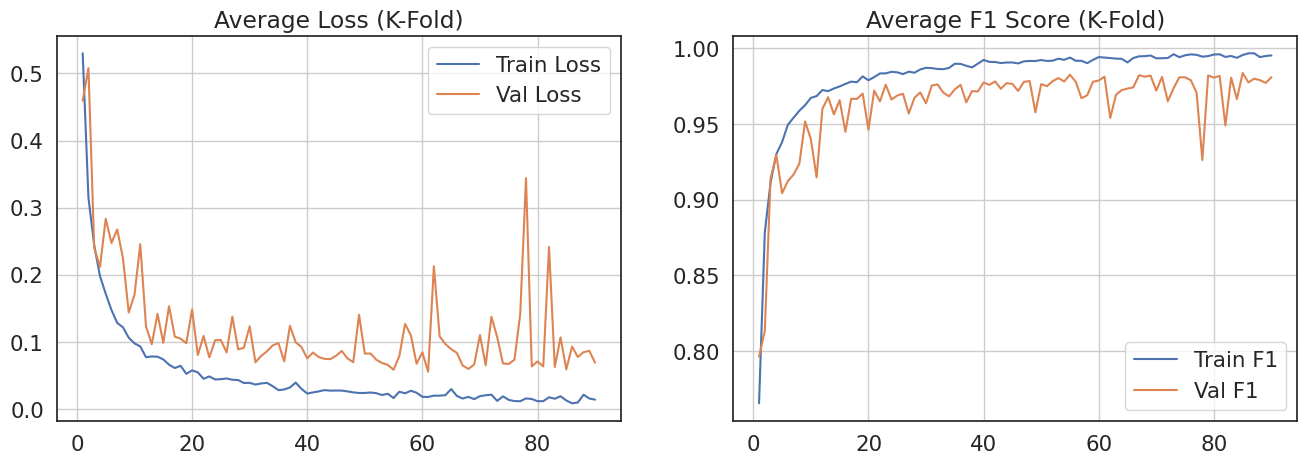


=== Arquitectura 2 ===
win=40, stride=20, cnn=64, lstm_hidden=64, lstm_layers=2


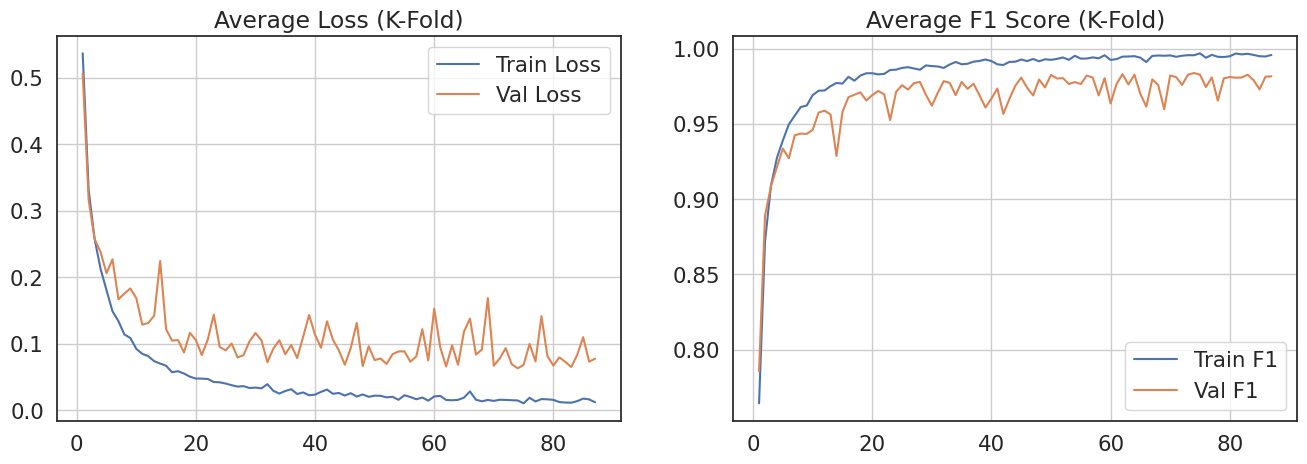


=== Arquitectura 3 ===
win=40, stride=20, cnn=64, lstm_hidden=128, lstm_layers=1


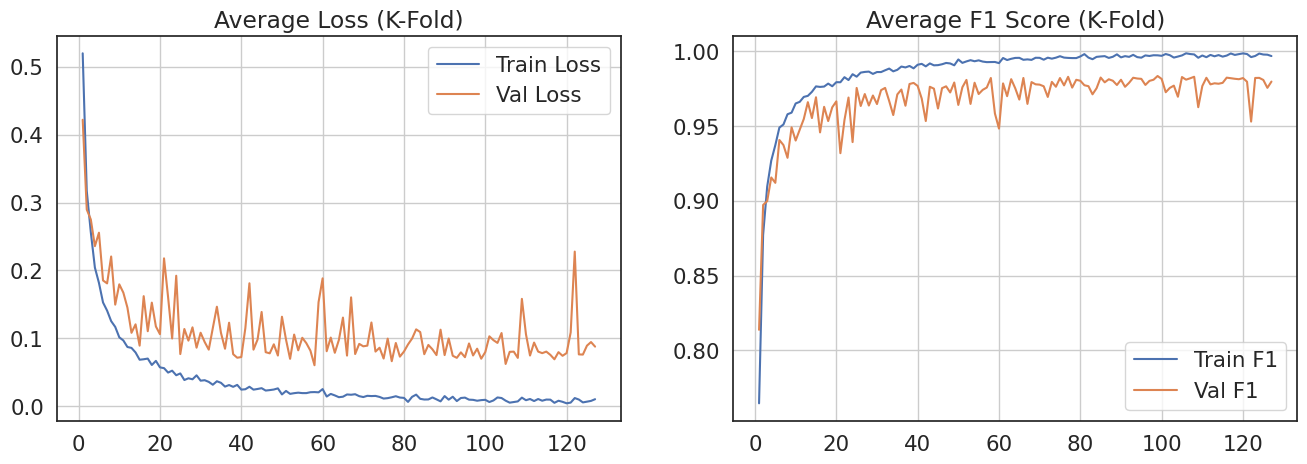


=== Arquitectura 4 ===
win=40, stride=20, cnn=64, lstm_hidden=128, lstm_layers=2


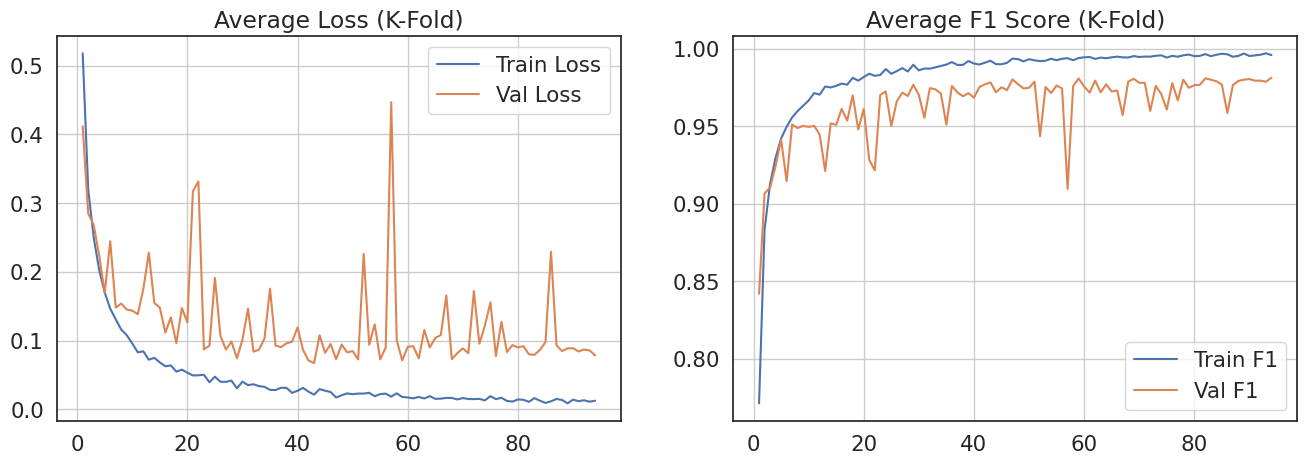

In [ ]:
for i, res in enumerate(results):
    print(f"\n=== Arquitectura {i+1} ===")
    print(f"win={res['window']}, stride={res['stride']}, cnn={res['cnn']}, lstm_hidden={res['lstm_hidden']}, lstm_layers={res['lstm_layers']}")

    plot_average_history_kfold(res)


=== Boxplot Arq 1 ===


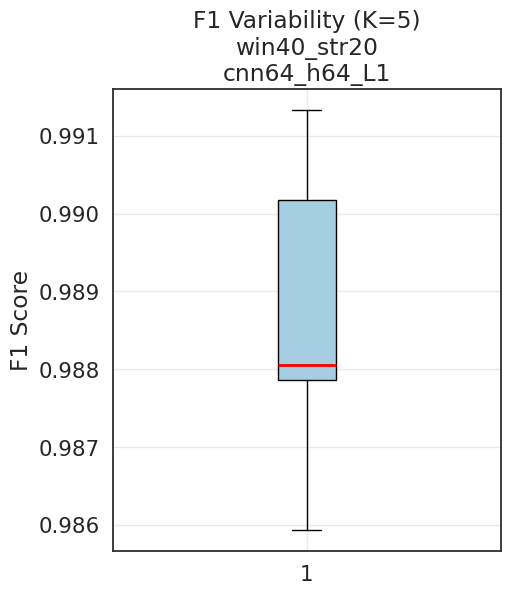


=== Boxplot Arq 2 ===


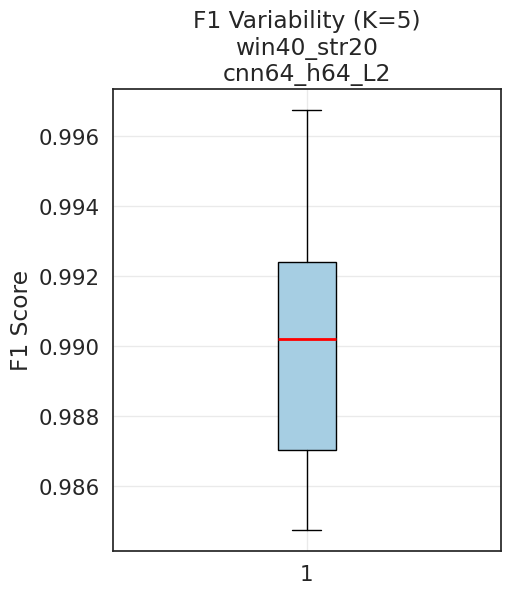


=== Boxplot Arq 3 ===


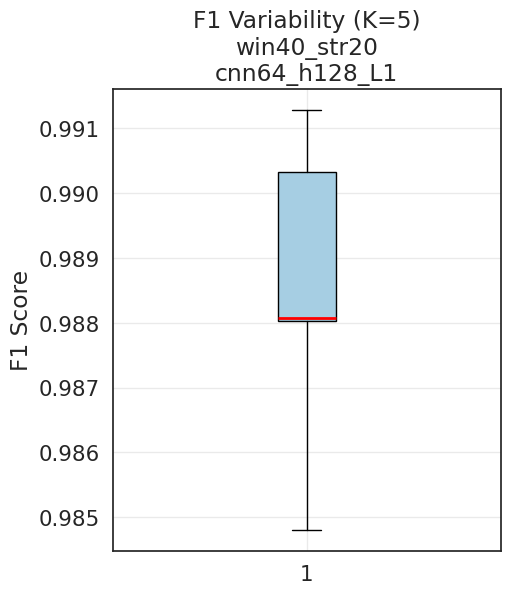


=== Boxplot Arq 4 ===


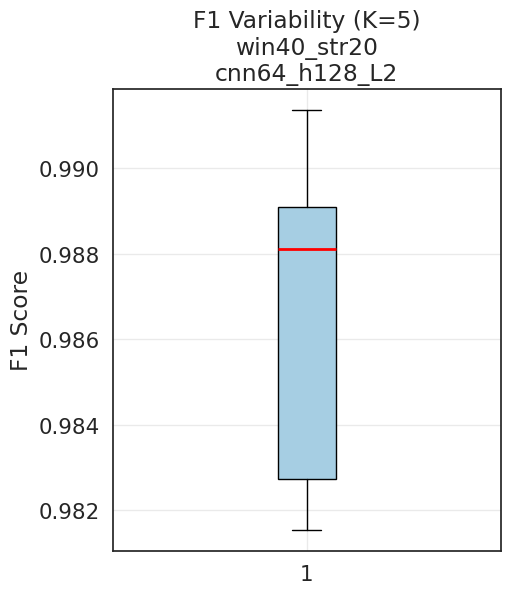

In [ ]:
for i, res in enumerate(results):
    print(f"\n=== Boxplot Arq {i+1} ===")
    plot_f1_boxplot(res)

In [ ]:
def plot_all_boxplots(results):
    """
    Muestra un único gráfico con boxplots de todas las arquitecturas entrenadas.
    Cada box representa los 5 F1 de los 5 folds.
    """

    # Extraer listas de F1
    all_scores = [res["fold_scores"] for res in results]

    # Crear nombres de configuración
    labels = [
        f"win{r['window']}_str{r['stride']}\ncnn{r['cnn']}_h{r['lstm_hidden']}_L{r['lstm_layers']}"
        for r in results
    ]

    plt.figure(figsize=(14, 6))
    plt.boxplot(
        all_scores,
        patch_artist=True,
        medianprops=dict(color="red", linewidth=2),
        boxprops=dict(facecolor="#a6cee3"),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
    )

    plt.xticks(range(1, len(labels) + 1), labels, rotation=20)
    plt.title("F1 Distribution Across Architectures (K-Fold)")
    plt.ylabel("F1 Score")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

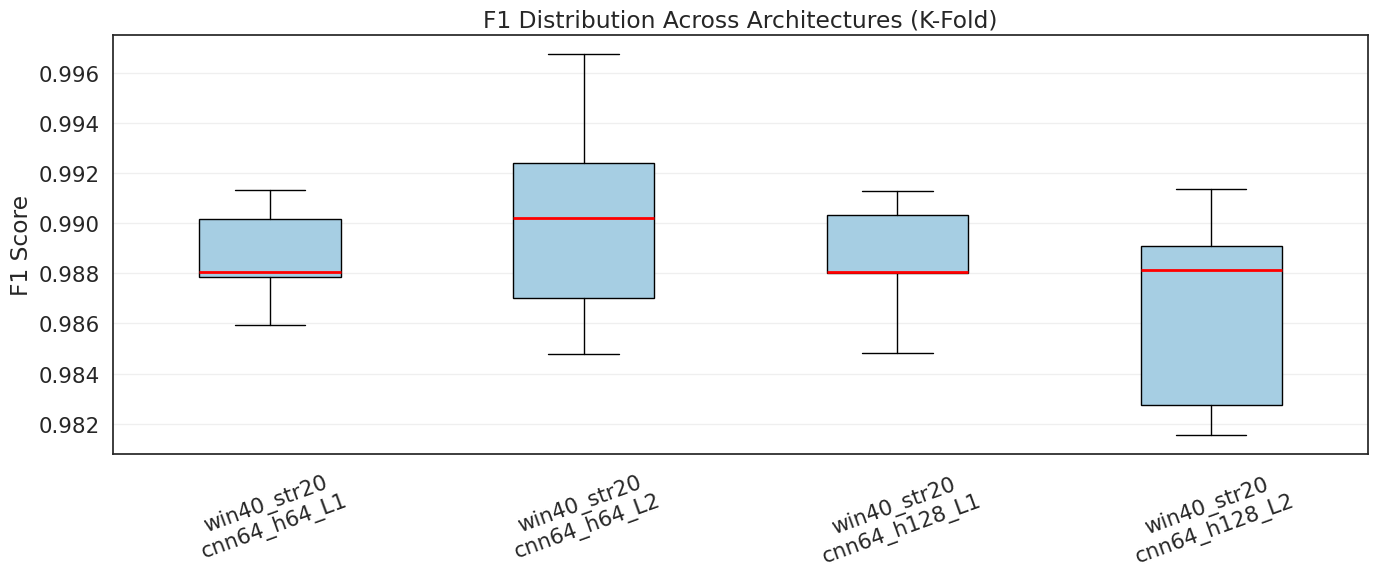

In [ ]:
plot_all_boxplots(results)

In [ ]:
## To plot confusion matrix
from sklearn.metrics import confusion_matrix

def compute_confusion_matrix_for_fold(
        fold_idx,
        result,
        X_all, y_all,
        device
    ):
    """Compute confusion matrix for one fold."""

    # 1. Load validation indices
    val_idx = result["fold_indices"][fold_idx]["val_idx"]
    X_val = X_all[val_idx]
    y_val = y_all[val_idx]

    # 2. Build DataLoader
    val_ds = TensorDataset(
        torch.from_numpy(X_val).float(),
        torch.from_numpy(y_val).long()
    )
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

    # 3. Load model
    cnn_ch      = result["cnn"]
    lstm_hid    = result["lstm_hidden"]
    lstm_layers = result["lstm_layers"]
    input_dim   = X_all.shape[-1]

    path = result["fold_paths"][fold_idx]

    model = CNN_LSTM_Attention(
        input_dim=input_dim,
        cnn_channels=cnn_ch,
        lstm_hidden=lstm_hid,
        lstm_layers=lstm_layers,
        num_classes=3,
        dropout=DROPOUT_RATE,
        bidirectional=True
    ).to(device)

    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()

    # 4. Inference
    preds = []
    targets = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            ps = logits.argmax(dim=1).cpu().numpy()

            preds.append(ps)
            targets.append(yb.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)

    # 5. Confusion matrix
    cm = confusion_matrix(targets, preds, labels=[0,1,2])

    return cm

In [ ]:
def compute_average_confusion_matrix(result, X_all, y_all, device):
    """Compute the average confusion matrix across all folds."""

    k = len(result["fold_paths"])
    cms = []

    for fold_idx in range(k):
        cm = compute_confusion_matrix_for_fold(
            fold_idx,
            result,
            X_all, y_all,
            device
        )
        cms.append(cm)

    avg_cm = np.mean(cms, axis=0)
    return avg_cm

In [ ]:
def plot_average_confusion_matrix(avg_cm):
    labels = ["no_pain", "low_pain", "high_pain"]

    plt.figure(figsize=(7,6))
    sns.heatmap(avg_cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Average Confusion Matrix (5-Fold)")
    plt.tight_layout()
    plt.show()

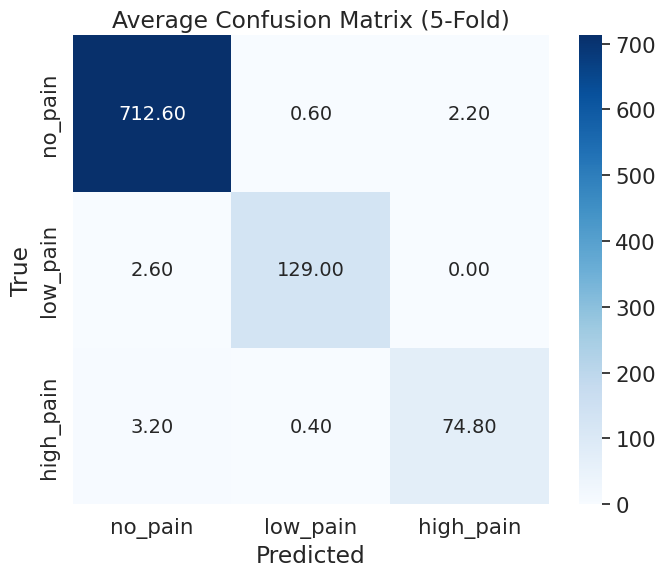

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_result = max(results, key=lambda x: x["avg_f1"])

avg_cm = compute_average_confusion_matrix(
    best_result,
    X_all,
    y_all,
    device
)

plot_average_confusion_matrix(avg_cm)

In [ ]:
## Confusion matrix for each fold
def load_best_fold_model(result, input_dim, device="cuda"):
    path = result["best_fold_path"]
    cnn = result["cnn"]
    hid = result["lstm_hidden"]
    layers = result["lstm_layers"]

    model = CNN_LSTM_Attention(
        input_dim=input_dim,
        cnn_channels=cnn,
        lstm_hidden=hid,
        lstm_layers=layers,
        num_classes=num_classes,
        dropout=DROPOUT_RATE,
        bidirectional=True
    ).to(device)

    state = torch.load(path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    return model

In [ ]:
def get_best_fold_predictions(result, X_all, y_all, BATCH_SIZE=64, device="cuda"):

    best_fold = result["best_fold_idx"]
    val_idx = result["fold_indices"][best_fold]["val_idx"]

    X_val = X_all[val_idx]
    y_val = y_all[val_idx]

    val_ds = TensorDataset(torch.from_numpy(X_val).float(),
                           torch.from_numpy(y_val).long())
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = load_best_fold_model(
        result,
        input_dim=X_all.shape[-1],
        device=device
    )

    preds, targets = [], []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = logits.argmax(1).cpu().numpy()
            preds.append(pred)
            targets.append(yb.numpy())

    preds   = np.concatenate(preds)
    targets = np.concatenate(targets)

    return preds, targets

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

label_names = ["no_pain", "low_pain", "high_pain"]

def plot_confusion_matrix(preds, targets):
    cm = confusion_matrix(targets, preds)

    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt="d",
                cmap="Blues",
                xticklabels=label_names,
                yticklabels=label_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix — Best Fold")
    plt.show()


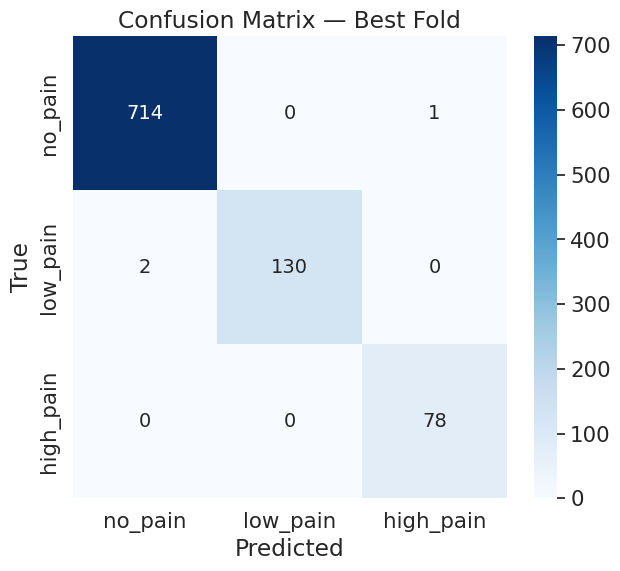

In [ ]:
preds, targets = get_best_fold_predictions(
    result=best_result,
    X_all=X_all,
    y_all=y_all,
    device=device
)

plot_confusion_matrix(preds, targets)

## As it is display in the confussion matrix the total sum is 925 that matches
# the number of window according

In [ ]:
best_global = max(results, key=lambda x: x["avg_f1"])

print("\n============================")
print("🏆 MEJOR MODELO GLOBAL")
print("============================")
print(best_global)

print("\n📌 PATH del mejor fold del mejor experimento:")
print(best_global["best_fold_path"])


🏆 MEJOR MODELO GLOBAL
{'window': 40, 'stride': 20, 'cnn': 64, 'lstm_hidden': 64, 'lstm_layers': 2, 'avg_f1': np.float64(0.9902278901656498), 'fold_scores': [0.9901980379629622, 0.9870289331982238, 0.9847632208028588, 0.9967530803714798, 0.9923961784927241], 'fold_paths': ['models/w40_s20_cnn64_lstm64_L2_20251117_153516/fold_1.pth', 'models/w40_s20_cnn64_lstm64_L2_20251117_153516/fold_2.pth', 'models/w40_s20_cnn64_lstm64_L2_20251117_153516/fold_3.pth', 'models/w40_s20_cnn64_lstm64_L2_20251117_153516/fold_4.pth', 'models/w40_s20_cnn64_lstm64_L2_20251117_153516/fold_5.pth'], 'fold_histories': [{'train_loss': [0.5530010686955301, 0.3580063998344878, 0.26044149897736946, 0.21626090257152034, 0.1852774876729761, 0.14260695010254557, 0.11938270831455962, 0.11896482475607242, 0.10020154806785538, 0.08323053952424277, 0.08793547910166831, 0.06924516432162428, 0.07335279582400993, 0.06459813216593951, 0.05960078408246595, 0.04966066148302195, 0.06281152233920269, 0.05925379453845457, 0.05738012

In [ ]:
# Route of best experiment
best_global["exp_dir"]

'models/w40_s20_cnn64_lstm64_L2_20251117_153516'

In [ ]:
## We get results
sorted_results = sorted(results, key=lambda x: x["avg_f1"], reverse=True)
print(type(sorted_results))
df_results = pd.DataFrame(sorted_results)
df_results

<class 'list'>


,window,stride,cnn,lstm_hidden,lstm_layers,avg_f1,fold_scores,fold_paths,fold_histories,fold_indices,best_fold_idx,best_fold_f1,best_fold_path,exp_dir
0,40,20,64,64,2,0.990228,"[0.9901980379629622, 0.9870289331982238, 0.984...",[models/w40_s20_cnn64_lstm64_L2_20251117_15351...,"[{'train_loss': [0.5530010686955301, 0.3580063...","[{'train_idx': [0, 1, 2, 4, 5, 7, 8, 9, 10, 11...",3,0.996753,models/w40_s20_cnn64_lstm64_L2_20251117_153516...,models/w40_s20_cnn64_lstm64_L2_20251117_153516
1,40,20,64,64,1,0.988671,"[0.9878586553529445, 0.9859330220626208, 0.988...",[models/w40_s20_cnn64_lstm64_L1_20251117_15244...,"[{'train_loss': [0.527701312200471, 0.32769932...","[{'train_idx': [0, 1, 2, 4, 5, 7, 8, 9, 10, 11...",3,0.991334,models/w40_s20_cnn64_lstm64_L1_20251117_152444...,models/w40_s20_cnn64_lstm64_L1_20251117_152444
2,40,20,64,128,1,0.988505,"[0.9880731009172952, 0.9848051365758342, 0.988...",[models/w40_s20_cnn64_lstm128_L1_20251117_1548...,"[{'train_loss': [0.5317540244777857, 0.3382294...","[{'train_idx': [0, 1, 2, 4, 5, 7, 8, 9, 10, 11...",4,0.991287,models/w40_s20_cnn64_lstm128_L1_20251117_15484...,models/w40_s20_cnn64_lstm128_L1_20251117_154849
3,40,20,64,128,2,0.986573,"[0.9815459940621476, 0.9827370103915363, 0.988...",[models/w40_s20_cnn64_lstm128_L2_20251117_1600...,"[{'train_loss': [0.521399824981978, 0.31910747...","[{'train_idx': [0, 1, 2, 4, 5, 7, 8, 9, 10, 11...",3,0.991372,models/w40_s20_cnn64_lstm128_L2_20251117_16004...,models/w40_s20_cnn64_lstm128_L2_20251117_160045


In [ ]:
## We obtained the top ones
top5 = sorted_results[:5]
df_top5 = pd.DataFrame([{
    "config": f"win{r['window']}_str{r['stride']}_cnn{r['cnn']}_h{r['lstm_hidden']}_L{r['lstm_layers']}",
    "avg_f1": r["avg_f1"]
} for r in top5])
df_top5

,config,avg_f1
0,win40_str20_cnn64_h64_L2,0.990228
1,win40_str20_cnn64_h64_L1,0.988671
2,win40_str20_cnn64_h128_L1,0.988505
3,win40_str20_cnn64_h128_L2,0.986573


In [ ]:
# cargamos los modelos
fold_models_cnn = []

for fold_idx in range(1, 6):
    model_path = f"{best_global['exp_dir']}/fold_{fold_idx}.pth"

    model = CNN_LSTM_Attention(
        input_dim=input_shape[-1],
        cnn_channels=best_global["cnn"],
        lstm_hidden=best_global["lstm_hidden"],
        lstm_layers=best_global["lstm_layers"],
        num_classes=num_classes,
        dropout=DROPOUT_RATE,
        bidirectional=True
    ).to(device)

    model.load_state_dict(torch.load(model_path))
    model.eval()

    fold_models_cnn.append(model)

In [ ]:
fold_models_cnn

[CNN_LSTM_Attention(
   (conv1): Conv1d(38, 64, kernel_size=(5,), stride=(1,), padding=(2,))
   (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
   (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (relu): ReLU()
   (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
   (attention): AttentionLayer(
     (attn): Linear(in_features=256, out_features=1, bias=True)
   )
   (fc): Sequential(
     (0): Dropout(p=0.2, inplace=False)
     (1): Linear(in_features=256, out_features=3, bias=True)
   )
 ),
 CNN_LSTM_Attention(
   (conv1): Conv1d(38, 64, kernel_size=(5,), stride=(1,), padding=(2,))
   (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
   (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=Tr

In [ ]:
sorted_results_3 = sorted(results, key=lambda x: x["avg_f1"], reverse=True)
top3_3 = sorted_results_3[:3]
for i, r in enumerate(top3_3):
    print(f"#{i+1}: F1={r['avg_f1']:.4f}  win={r['window']}  str={r['stride']} "
          f"cnn={r['cnn']} hid={r['lstm_hidden']} L={r['lstm_layers']} exp_dit={r['exp_dir']}")

#1: F1=0.9902  win=40  str=20 cnn=64 hid=64 L=2 exp_dit=models/w40_s20_cnn64_lstm64_L2_20251117_153516
#2: F1=0.9887  win=40  str=20 cnn=64 hid=64 L=1 exp_dit=models/w40_s20_cnn64_lstm64_L1_20251117_152444
#3: F1=0.9885  win=40  str=20 cnn=64 hid=128 L=1 exp_dit=models/w40_s20_cnn64_lstm128_L1_20251117_154849


### Preparing test data for inference

In [ ]:
best_window = 40   # cambia según el resultado de tus pruebas
best_stride = 20   # cambia también si es necesario

In [ ]:
## VERSION 2

def build_sequences_test_3(df, feature_list, window, stride):
    seqs = []
    ids = []

    for sid in df['sample_index'].unique():
        temp = df[df['sample_index'] == sid][feature_list].values.astype(np.float32)

        idx = 0
        while idx + window <= len(temp):
            seqs.append(temp[idx:idx+window])
            ids.append(sid)   # <-- AQUÍ EL FIX: UN ID POR VENTANA
            idx += stride

    return np.array(seqs), np.array(ids)

In [ ]:
from torch.utils.data import Dataset
class PirateTestDataset(Dataset):
    def __init__(self, X, ids):
        self.X = X
        self.ids = ids

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)   # (160, 35)
        sid = self.ids[idx]
        return x, sid

In [ ]:
X_test_kaggle = None
X_test_kaggle, test_ids_kaggle= build_sequences_test_3(test_kaggle, feature_list ,best_window, best_stride)
X_test_kaggle.shape

(9268, 40, 37)

In [ ]:
print(X_test_kaggle.shape)      # (3972, 80, 38)
print(test_ids_kaggle.shape)    # (3972,)

(9268, 40, 37)
(9268,)


In [ ]:
test_dataset_kaggle = PirateTestDataset(X_test_kaggle, test_ids_kaggle)
test_loader_kaggle  = DataLoader(test_dataset_kaggle, batch_size=64, shuffle=False)

In [ ]:
### Ensemble between 5 folds
def predict_ensemble_test(fold_models, test_loader, device='cuda'):
    all_probs = []

    for model in fold_models:
        model.eval()
        fold_probs = []

        with torch.no_grad():
            for X_batch, sid_batch in test_loader:
                X_batch = X_batch.to(device)
                logits = model(X_batch)
                probs = logits.softmax(dim=1).cpu().numpy()
                fold_probs.append(probs)

        fold_probs = np.concatenate(fold_probs, axis=0)
        all_probs.append(fold_probs)

    # folds average
    final_probs = np.mean(all_probs, axis=0)
    final_preds = np.argmax(final_probs, axis=1)
    return final_preds

In [ ]:
## We map int values to str
label_map = {0: "no_pain", 1: "low_pain", 2: "high_pain"}

In [ ]:
import torch

def load_fold_models_GRID(exp_dir, cnn_channels, lstm_hidden, lstm_layers, input_size, num_classes=3, device="cuda"):

    fold_models = []

    for fold_idx in range(1, 6):
        path = f"{exp_dir}/fold_{fold_idx}.pth"

        model = CNN_LSTM_Attention(
            input_dim=input_size,
            cnn_channels=cnn_channels,
            lstm_hidden=lstm_hidden,
            lstm_layers=lstm_layers,
            num_classes=num_classes
        ).to(device)

        model.load_state_dict(torch.load(path, map_location=device))
        model.eval()

        fold_models.append(model)

    return fold_models

In [ ]:
def build_test_sequences_GRID(df_test, feature_list, window, stride):
    X_list = []
    ids_list = []

    for sid in df_test["sample_index"].unique():
        temp = df_test[df_test["sample_index"] == sid][feature_list].values

        idx = 0
        while idx + window <= len(temp):
            X_list.append(temp[idx:idx+window])
            ids_list.append(sid)
            idx += stride

    return np.array(X_list), np.array(ids_list)

In [ ]:
def predict_ensemble_test_GRID(fold_models, test_loader, device="cuda"):
    all_probs = []

    for model in fold_models:
        model.eval()
        fold_probs = []

        with torch.no_grad():
            for X_batch, sid_batch in test_loader:
                X_batch = X_batch.to(device)
                logits = model(X_batch)
                probs = logits.softmax(dim=1).cpu().numpy()
                fold_probs.append(probs)

        all_probs.append(np.concatenate(fold_probs, axis=0))

    final_probs = np.mean(all_probs, axis=0)
    final_preds = np.argmax(final_probs, axis=1)
    return final_preds

In [ ]:
import numpy as np
from collections import Counter

def aggregate_by_majority_vote(test_ids, preds):
    """
    test_ids: array size (#windows) with sample_index of each window
    preds:    array size (#windows) with prediction of each window
    """
    final_preds = np.zeros(1324, dtype=int)

    unique_ids = np.arange(1324)

    for sid in unique_ids:
        # get indexes
        idx = np.where(test_ids == sid)[0]

        if len(idx) == 0:
            final_preds[sid] = 0
            continue

        # get predictions
        votes = preds[idx]

        # Majority vote
        most_common = Counter(votes).most_common(1)[0][0]
        final_preds[sid] = most_common

    return final_preds

In [ ]:
for i, cfg in enumerate(top3_3):

    print(f"\n==============================")
    print(f"🚀 PROBANDO CONFIG #{i+1}")
    print("==============================")

    window     = cfg["window"]
    stride     = cfg["stride"]
    cnn_ch     = cfg["cnn"]
    lstm_hid   = cfg["lstm_hidden"]
    lstm_layers= cfg["lstm_layers"]
    exp_dir    = cfg["exp_dir"]

    # 1. building test sequences
    X_test, test_ids = build_test_sequences_GRID(test_kaggle, feature_list, window, stride)

    test_dataset = PirateTestDataset(X_test, test_ids)
    test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

    # 2. loading models
    fold_models = load_fold_models_GRID(
        exp_dir=exp_dir,
        cnn_channels=cnn_ch,
        lstm_hidden=lstm_hid,
        lstm_layers=lstm_layers,
        input_size=X_test.shape[-1]
    )

    # 3. inference ensemble
    preds = predict_ensemble_test(fold_models, test_loader, device=device)

    # 4. convert for sample index
    final_labels = aggregate_by_majority_vote(test_ids, preds)

    # 5. prepararing dataframe
    df_sub = pd.DataFrame({
        "sample_index": np.arange(1324),
        "label": [label_map[x] for x in final_labels]
    })

    df_sub.to_csv(f"submission_grid_last_top{i+1}.csv", index=False)
    print(f"✔ submission_grid_last_top{i+1}.csv guardado")
    print(f"exp_dir: {exp_dir}")


🚀 PROBANDO CONFIG #1
✔ submission_grid_last_top1.csv guardado
exp_dir: models/w40_s20_cnn64_lstm64_L2_20251117_153516

🚀 PROBANDO CONFIG #2
✔ submission_grid_last_top2.csv guardado
exp_dir: models/w40_s20_cnn64_lstm64_L1_20251117_152444

🚀 PROBANDO CONFIG #3
✔ submission_grid_last_top3.csv guardado
exp_dir: models/w40_s20_cnn64_lstm128_L1_20251117_154849
